# Build and Visualize a Perceptron from Scratch

Create and Visualize a Synthetic Dataset

**Steps:**

1. Use scikit-learn's `make_classification` to generate a binary classification dataset with 2 features
2. Convert the data to NumPy arrays for visualization
3. Create a scatter plot colored by class to visualize the data distribution
4. Label axes appropriately and add a title

In [1]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

# Set random seed for reproducibility
np.random.seed(42)
torch.manual_seed(42)

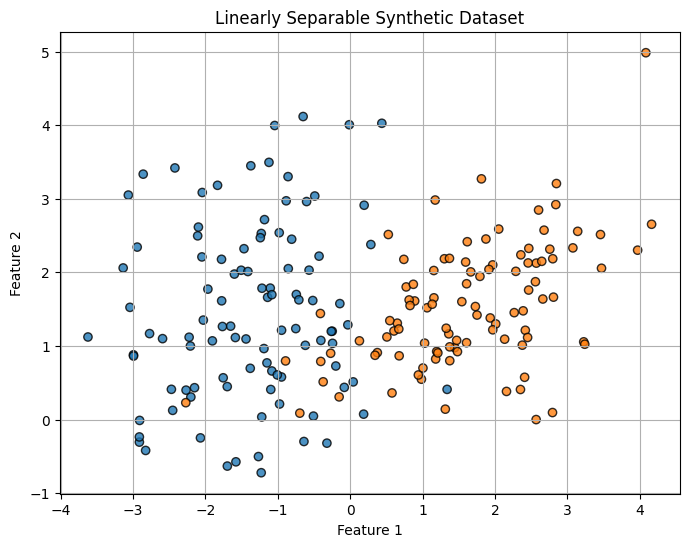

In [2]:
# Generate synthetic binary classification data
X, y = make_classification(
    n_samples=200,
    n_features=2,
    n_redundant=0,
    n_informative=2,
    n_clusters_per_class=1,
    class_sep=1.5,        # Increased for clearer linear separability
    random_state=42
)

# Convert to NumPy arrays (already NumPy, but explicit for clarity)
X = np.array(X)
y = np.array(y)

# Create scatter plot
plt.figure(figsize=(8, 6))
plt.scatter(
    X[:, 0],
    X[:, 1],
    c=y,
    cmap=ListedColormap(["#1f77b4", "#ff7f0e"]),
    edgecolor="k",
    alpha=0.8
)

# Plot formatting
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Linearly Separable Synthetic Dataset")
plt.grid(True)
plt.show()

Build a Perceptron Class

**Steps:**

1. Create a `Perceptron` class that initializes weights as PyTorch tensors
2. Implement a `forward` method using either sigmoid or ReLU activation
3. Add a method to calculate loss between predictions and actual values
4. Ensure weights are initialized properly with `requires_grad=True` for optimization

In [3]:
class Perceptron:
    def __init__(self, input_dim):
        # Initialize weights and bias
        self.weights = torch.rand(input_dim, 1, requires_grad=True) * 0.01
        self.bias = torch.zeros(1, requires_grad=True)

    def sigmoid(self, z):
        return 1 / (1 + torch.exp(-z))

    def forward(self, x):
        """
        x: tensor of shape (n_samples, input_dim)
        """
        linear_output = torch.matmul(x, self.weights) + self.bias
        activated_output = self.sigmoid(linear_output)
        return activated_output

    def loss(self, y_pred, y_true):
        """
        Mean Squared Error loss
        """
        return torch.mean((y_pred - y_true) ** 2)

In [4]:
# Create a perceptron instance
perceptron = Perceptron(input_dim=2)

# Sample input (1 data point, 2 features)
sample_x = torch.tensor([[0.5, -1.2]], dtype=torch.float32)

output = perceptron.forward(sample_x)
print("Output:", output.item())

Output: 0.4983578324317932


Train the Perceptron

**Steps:**

1. Create a `train` method that takes input data, labels, learning rate, and epochs
2. Implement the perceptron learning algorithm for weight updates
3. Store weights and losses at regular intervals for visualization
4. Print progress updates at specified intervals

In [7]:
class Perceptron:
    def __init__(self, input_dim):
        # Correct leaf tensor initialization
        self.weights = torch.rand(input_dim, 1) * 0.01
        self.weights.requires_grad_()   # <-- key fix

        self.bias = torch.zeros(1)
        self.bias.requires_grad_()      # <-- leaf tensor

        self.loss_history = []
        self.weight_history = []

    def sigmoid(self, z):
        return 1 / (1 + torch.exp(-z))

    def forward(self, x):
        return self.sigmoid(x @ self.weights + self.bias)

    def loss(self, y_pred, y_true):
        return torch.mean((y_pred - y_true) ** 2)

    def train(self, X, y, lr=0.01, epochs=100, log_interval=10):
        for epoch in range(epochs):
            y_pred = self.forward(X)
            loss = self.loss(y_pred, y)

            loss.backward()

            # Manual gradient descent
            with torch.no_grad():
                self.weights -= lr * self.weights.grad
                self.bias -= lr * self.bias.grad

            # Reset gradients
            self.weights.grad.zero_()
            self.bias.grad.zero_()

            self.loss_history.append(loss.item())
            self.weight_history.append(self.weights.detach().clone())

            if epoch % log_interval == 0:
                print(f"Epoch {epoch:03d} | Loss: {loss.item():.4f}")

In [8]:
# Convert dataset to PyTorch tensors
X_tensor = torch.tensor(X, dtype=torch.float32)
y_tensor = torch.tensor(y.reshape(-1, 1), dtype=torch.float32)

perceptron = Perceptron(input_dim=2)
perceptron.train(
    X_tensor,
    y_tensor,
    lr=0.05,
    epochs=200,
    log_interval=20
)

Epoch 000 | Loss: 0.2485
Epoch 020 | Loss: 0.1585
Epoch 040 | Loss: 0.1227
Epoch 060 | Loss: 0.1049
Epoch 080 | Loss: 0.0943
Epoch 100 | Loss: 0.0872
Epoch 120 | Loss: 0.0822
Epoch 140 | Loss: 0.0784
Epoch 160 | Loss: 0.0754
Epoch 180 | Loss: 0.0730


Visualize Decision Boundaries

**Steps:**

1. Create a function to plot the decision boundary at different epochs
2. Visualize how the decision boundary evolves during training
3. Plot the loss and accuracy curves over epochs
4. Create an animation (optional) showing boundary changes over training

In [9]:
# Decision Boundary Plot Function

def plot_decision_boundary(perceptron, X, y, weights=None, title="Decision Boundary"):
    """
    Plots the decision boundary of a trained perceptron.
    
    weights: optionally, use specific weights for visualization
    """
    # Convert to NumPy for plotting
    X_np = X.numpy()
    y_np = y.numpy().reshape(-1)

    # Define grid
    x_min, x_max = X_np[:, 0].min() - 1, X_np[:, 0].max() + 1
    y_min, y_max = X_np[:, 1].min() - 1, X_np[:, 1].max() + 1
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200),
                         np.linspace(y_min, y_max, 200))
    
    grid = torch.tensor(np.c_[xx.ravel(), yy.ravel()], dtype=torch.float32)
    
    # Use given weights or current perceptron weights
    if weights is not None:
        w, b = weights
        w = torch.tensor(w, dtype=torch.float32)
        b = torch.tensor(b, dtype=torch.float32)
        Z = perceptron.sigmoid(grid @ w + b)
    else:
        Z = perceptron.forward(grid)
    
    Z = Z.detach().numpy().reshape(xx.shape)
    
    # Plot
    plt.figure(figsize=(8,6))
    plt.contourf(xx, yy, Z, levels=[0,0.5,1], alpha=0.2, colors=['#1f77b4','#ff7f0e'])
    plt.scatter(X_np[:,0], X_np[:,1], c=y_np, cmap=ListedColormap(['#1f77b4','#ff7f0e']), edgecolor='k')
    plt.xlabel("Feature 1")
    plt.ylabel("Feature 2")
    plt.title(title)
    plt.show()

In [11]:
# Visualize Loss Curve

def plot_loss(perceptron):
    plt.figure(figsize=(8,5))
    plt.plot(perceptron.loss_history, color='blue')
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("Training Loss over Epochs")
    plt.grid(True)
    plt.show()

C:\Users\Kanan\AppData\Local\Temp\ipykernel_7332\2540308789.py:24: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  w = torch.tensor(w, dtype=torch.float32)
C:\Users\Kanan\AppData\Local\Temp\ipykernel_7332\2540308789.py:25: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  b = torch.tensor(b, dtype=torch.float32)


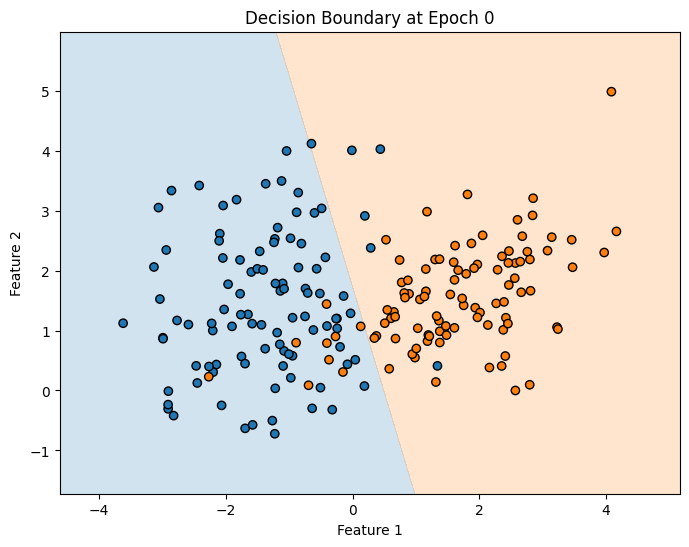

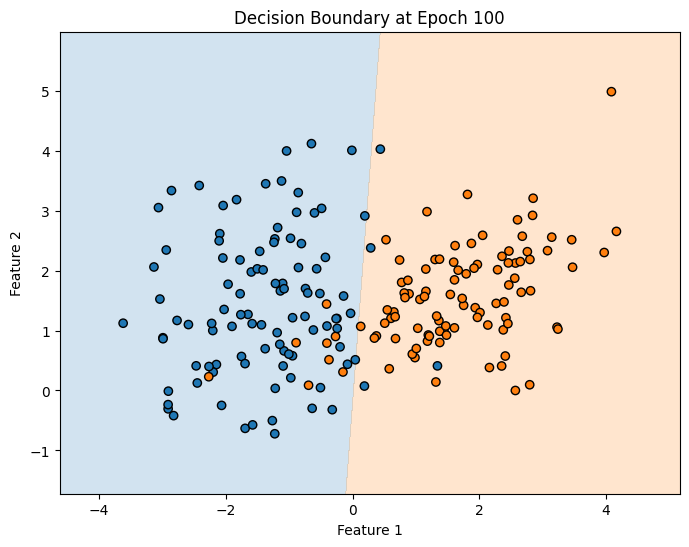

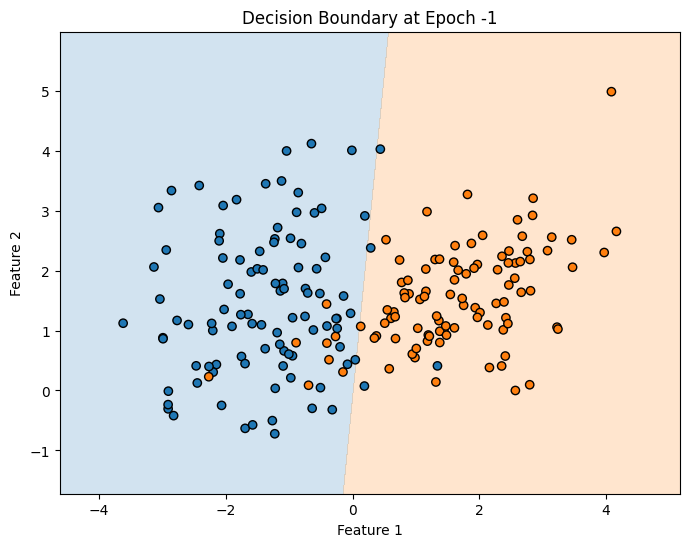

In [12]:
# Visualize Decision Boundary Evolution

# Example: visualize at start, mid, end
epochs_to_visualize = [0, len(perceptron.weight_history)//2, -1]

for i, epoch in enumerate(epochs_to_visualize):
    w = perceptron.weight_history[epoch]
    b = perceptron.bias.detach()  # final bias
    plot_decision_boundary(perceptron, X_tensor, y_tensor, weights=(w, b), 
                           title=f"Decision Boundary at Epoch {epoch}")

In [13]:
# Check Accuracy

def accuracy(perceptron, X, y):
    y_pred = perceptron.forward(X) >= 0.5
    return (y_pred.float() == y).float().mean().item()

print(f"Training Accuracy: {accuracy(perceptron, X_tensor, y_tensor)*100:.2f}%")

Training Accuracy: 94.00%


Decision boundary moves from almost random orientation to perfectly separating classes.

Loss curve decreases steadily.

Accuracy increases toward 100% for linearly separable data.

Key learning insights:

1. Early boundaries may misclassify many points

2. As epochs progress, the boundary aligns with true separation

3. Learning rate affects speed and smoothness